# Clustering

Ovaj nootebok služi za analizu clustera

---


## 1️. Uvoz biblioteka i podešavanje putanje

Prvo podešavamo putanju kako bi mogli uvesti svoje funkcije. Zatim uvozimo potrebne pakete za parsiranje PGN datoteka i vizualizaciju podataka te iz direktorija src uvozimo dvije funkcije koje će nam pomoći u analizi parse_games i extract_features i funkcije iz clustering.py.

In [ ]:
import os
import sys

sys.path.append(os.path.abspath("../src"))

In [23]:
import matplotlib.pylab as plt
import numpy as np
from features import extract_features
from parser import parse_games
import clustering

---

## 2. Parsiranje i izvlačenje feature-a

In [5]:
player_games, opening_count, num_of_games = parse_games("../data/raw/lichess_db_standard_rated_2013-01.pgn", 20)
players_feat_vectors = []
for games in player_games.values():
    feat_vector = extract_features(games, num_of_moves=10)
    players_feat_vectors.append(feat_vector)
players_feat_vectors = np.array(players_feat_vectors)

---

## 3. Normalizacija dobivene feature matrice

In [6]:
scaled_matrix, data_mean, data_std = clustering.normalize(players_feat_vectors)

print(scaled_matrix[0])

[-0.57385367  0.26135774  0.12574963  0.04848365 -0.80693868  0.96086545
 -1.0920244  -0.31119557  0.05935344  0.26653705  2.13797166 -0.79845553]


---


## 4. Pronalazak najboljeg k za klastere

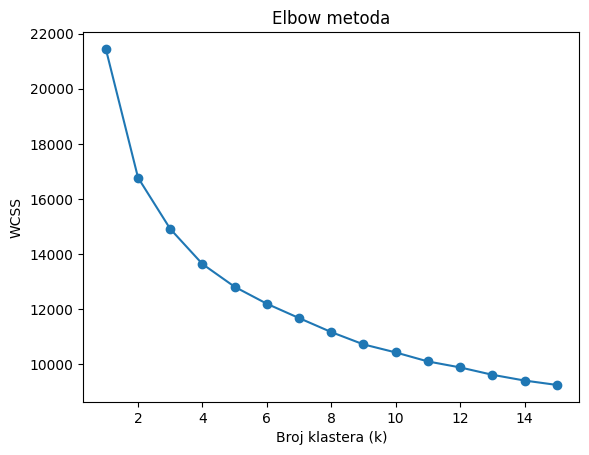

In [ ]:
wcss = clustering.find_optimal_k(scaled_matrix, 15)

---

## 5. Stvaranje i evaluacija, vizualizacija modela s najboljim k

Silhouette score for 3 is: 0.139
Davies Bouldin score for 3 is: 1.913


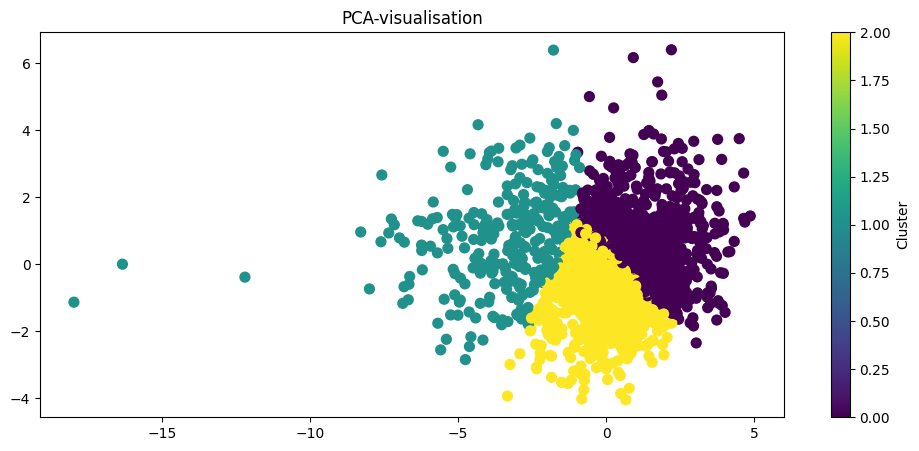

Silhouette score for 4 is: 0.136
Davies Bouldin score for 4 is: 1.792


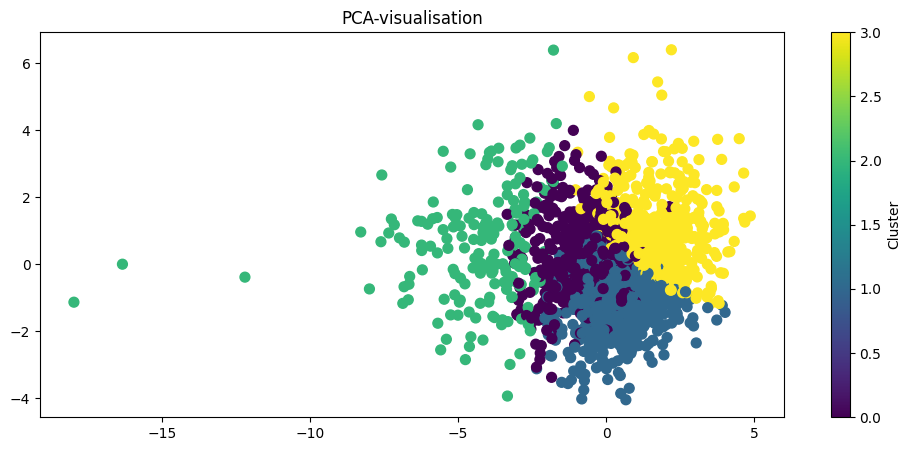

Silhouette score for 5 is: 0.131
Davies Bouldin score for 5 is: 1.516


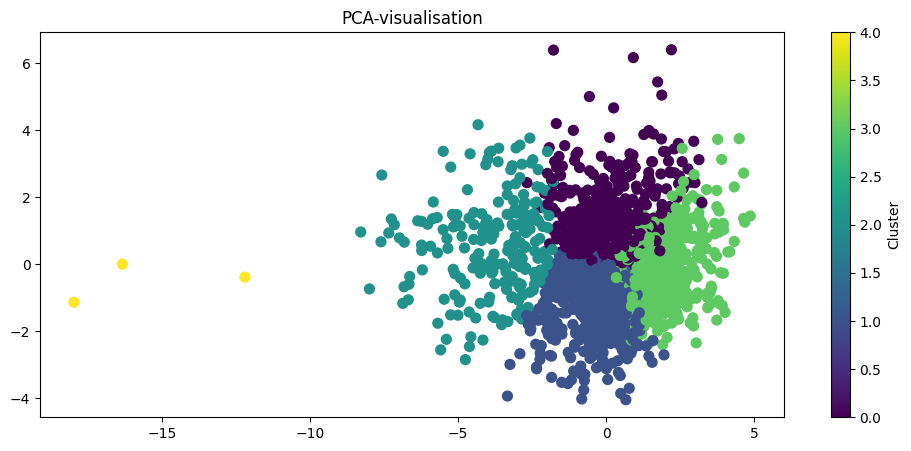

Silhouette score for 6 is: 0.129
Davies Bouldin score for 6 is: 1.712


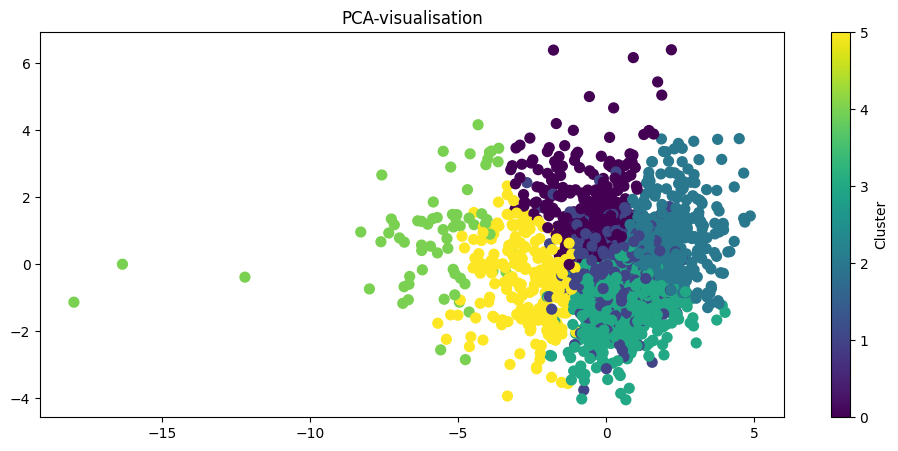

In [10]:
for k in [3, 4, 5, 6]:
    model, labels = clustering.fit_clusters(scaled_matrix, k)
    sil, db = clustering.evaluate_clusters(scaled_matrix, labels)
    print(f"Silhouette score for {k} is: {sil:.3f}")
    print(f"Davies Bouldin score for {k} is: {db:.3f}")
    clustering.visualize_clusters(scaled_matrix, labels)


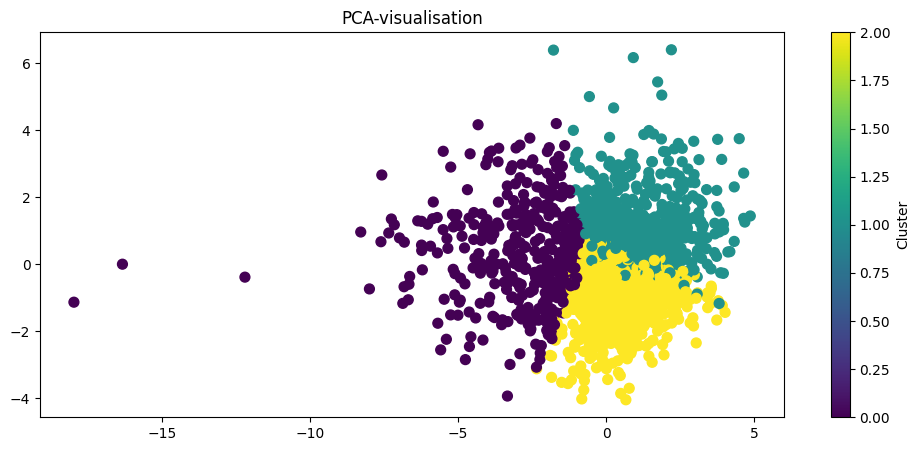

In [14]:
model, labels = clustering.fit_clusters(scaled_matrix, 3)
clustering.visualize_clusters(scaled_matrix, labels)

In [25]:
features_names = [
    "CPS",
    "SCN",
    "SS",
    "ECN",
    "EC",
    "DS",
    "RM",
    "CP",
    "CD",
    "AM",
    "CG",
    "PMR"
]
profile = clustering.profile_clusters(players_feat_vectors, labels, features_names)

print(profile.to_string())


           CPS    SCN     SS    ECN     EC  ...     CP     CD     AM     CG    PMR
cluster                                     ...                                   
0        2.262  0.066  0.187  0.095  0.193  ...  0.361  0.476  0.250  0.085  0.293
1        2.384  0.058  0.157  0.086  0.153  ...  0.549  0.366  0.236  0.070  0.297
2        2.059  0.052  0.143  0.069  0.149  ...  0.171  0.675  0.216  0.066  0.335

[3 rows x 12 columns]
           CPS    SCN     SS    ECN     EC     DS     RM     CP     CD     AM     CG    PMR
cluster                                                                                    
0        2.262  0.066  0.187  0.095  0.193  0.476  0.032  0.361  0.476  0.250  0.085  0.293
1        2.384  0.058  0.157  0.086  0.153  0.486  0.033  0.549  0.366  0.236  0.070  0.297
2        2.059  0.052  0.143  0.069  0.149  0.377  0.036  0.171  0.675  0.216  0.066  0.335


---


## 6. Interpretacija dobivenih klastera

### Klaster 0 - "Agresivni tip igrača"
| Metrika | Vrijednost | Opis |
|--------|------------|------|
| CPS    | 2.262      | visok pritisak na centar |
| SCN    | 0.066      | najviše žrtava |
| AM     | 0.250      | najviše napada |
| CG     | 0.085      | najviše šahova |
| CP     | 0.361      | rjeđe rošira |
| CD     | 0.476      | kasna rošada |

Obrazloženje: Igrač koji aktivno napada, ne boji se žrtvovati figure za inicijativu, kasno rošira ili uopće ne rošira jer mu je kralj zapeo u centru usred napada. Preferira otvorene pozicije s taktičkim komplikacijama.      

---     
### Klaster 1 "Pozicijski tip igrača"
| Metrika | Vrijednost | Opis |
|--------|------------|------|
| CPS    | 2.384        | najviši pritisak na centar |
| DS    | 0.486      | najbolji razvoj figura|
| CP     | 0.549       | najčešće rošira|
| CD     | 0.366     | najbrža rošada |
| AM     | 0.236     | manje direktnih napada |
| SCN     | 0.058     | malo žrtava |

Obrazloženje: Igrač koji brzo razvija figure, osigurava kralja rošadom, kontrolira centar bez nepotrebnih rizika. Preferira zatvorene pozicije gdje dolazi do izražaja dugoročna strategija.      
  
---
### Klaster 2 - Ekspirmentalni tip igrača

| Metrika | Vrijednost | Opis |
|--------|------------|----------------------------|
| CPS    | 2.059      | najniži pritisak na centar |
| DS     | 0.377      | najslabiji razvoj |
| CP     | 0.171      | rijetko rošira |
| CD     | 0.675      | najkasnija rošada |
| PMR    | 0.335      | najviše pješačkih poteza |
| RM     | 0.036      | najviše ponavljanja poteza |

Obrazloženje: Igrač koji zanemaruje osnovna načela otvaranja, slabo razvija figure, igra previše pješacima umjesto figurama, kasno ili nikad ne rošira. Može biti neiskusan igrač ili netko tko eksperimentira s nestandardnim otvaranjima.

---

## 7. Spremanje klastera

In [26]:
player_names = list(player_games.keys())
clustering.save_clusters(player_names, labels, "../data/processed/clusters.csv")